In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics      import mean_absolute_error

In [2]:
df = pd.read_csv('../data/ser_madrid/tickets_horas_barrios.csv', parse_dates=['fecha_hora'])

In [39]:
df.sample(3)

,fecha_hora,barrio,ocupacion_%,hora,dia_semana,ocupacion_1h_antes,target
164548,2024-04-18 20:00:00,san pascual,0.084866,20,3,0.141443,0.000000
434587,2024-10-14 11:00:00,castellana,0.000000,11,0,0.000000,0.000000
308281,2024-07-22 22:00:00,cuatro caminos,0.104493,22,0,0.104493,0.104493


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553266 entries, 0 to 553265
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   fecha_hora          553266 non-null  datetime64[ns]
 1   barrio              553266 non-null  object        
 2   ocupacion_%         553266 non-null  float64       
 3   hora                553266 non-null  int64         
 4   dia_semana          553266 non-null  int64         
 5   ocupacion_1h_antes  553266 non-null  float64       
 6   target              553266 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(1)
memory usage: 29.5+ MB


In [41]:
df.describe()

,fecha_hora,ocupacion_%,hora,dia_semana,ocupacion_1h_antes,target
count,553266,553266.000000,553266.000000,553266.000000,553266.000000,553266.000000
mean,2024-07-01 23:29:59.999999744,0.028870,11.500000,2.986905,0.028868,0.028872
min,2024-01-01 01:00:00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2024-04-01 12:00:00,0.000000,6.000000,1.000000,0.000000,0.000000
50%,2024-07-01 23:30:00,0.000000,11.500000,3.000000,0.000000,0.000000
75%,2024-10-01 11:00:00,0.000000,17.000000,5.000000,0.000000,0.000000
max,2024-12-31 22:00:00,3.053435,23.000000,6.000000,3.053435,3.053435
std,NaN,0.080799,6.920805,2.003230,0.080799,0.080800


<h3 style="color:yellow">Visualizaciones</3>

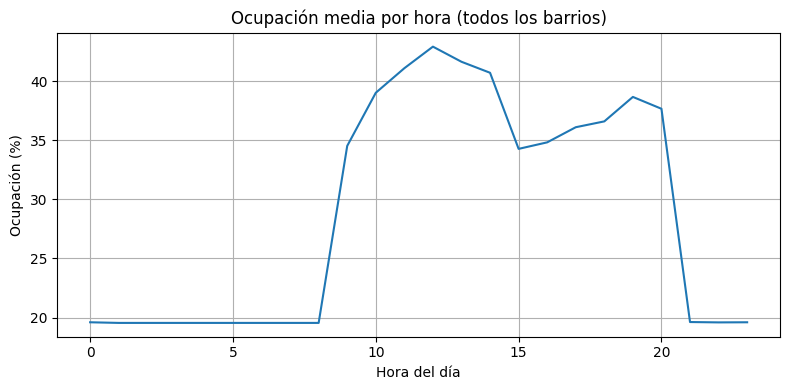

In [ ]:
#Promedio de ocupación por hora (todos los barrios)
############### x 1000 porque estamos utilizando una pequeña muestra ################
mean_by_hour = (df.groupby("hora")["ocupacion_%"].mean() * 1000)

plt.figure(figsize=(8, 4))
mean_by_hour.plot()
plt.title("Ocupación media por hora (todos los barrios)")
plt.xlabel("Hora del día")
plt.ylabel("Ocupación (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

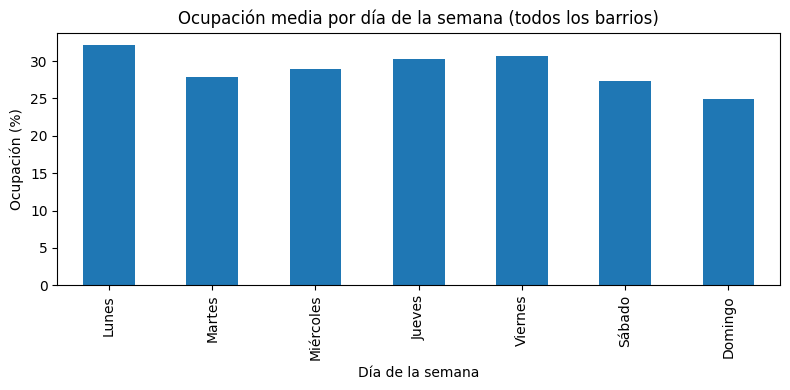

In [ ]:
Promedio de ocupación por día de la semana
day_names = {0: "Lunes", 1: "Martes", 2: "Miércoles", 3: "Jueves",
             4: "Viernes", 5: "Sábado", 6: "Domingo"}

############### x 1000 porque estamos utilizando una pequeña muestra ################
mean_by_day = df.groupby("dia_semana")["ocupacion_%"].mean() * 1000
mean_by_day.index = mean_by_day.index.map(day_names)

plt.figure(figsize=(8, 4))
mean_by_day.plot(kind="bar")
plt.title("Ocupación media por día de la semana (todos los barrios)")
plt.xlabel("Día de la semana")
plt.ylabel("Ocupación (%)")
plt.tight_layout()
plt.show()

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553266 entries, 0 to 553265
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   fecha_hora          553266 non-null  datetime64[ns]
 1   barrio              553266 non-null  object        
 2   ocupacion_%         553266 non-null  float64       
 3   hora                553266 non-null  int64         
 4   dia_semana          553266 non-null  int64         
 5   ocupacion_1h_antes  553266 non-null  float64       
 6   target              553266 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(1)
memory usage: 29.5+ MB


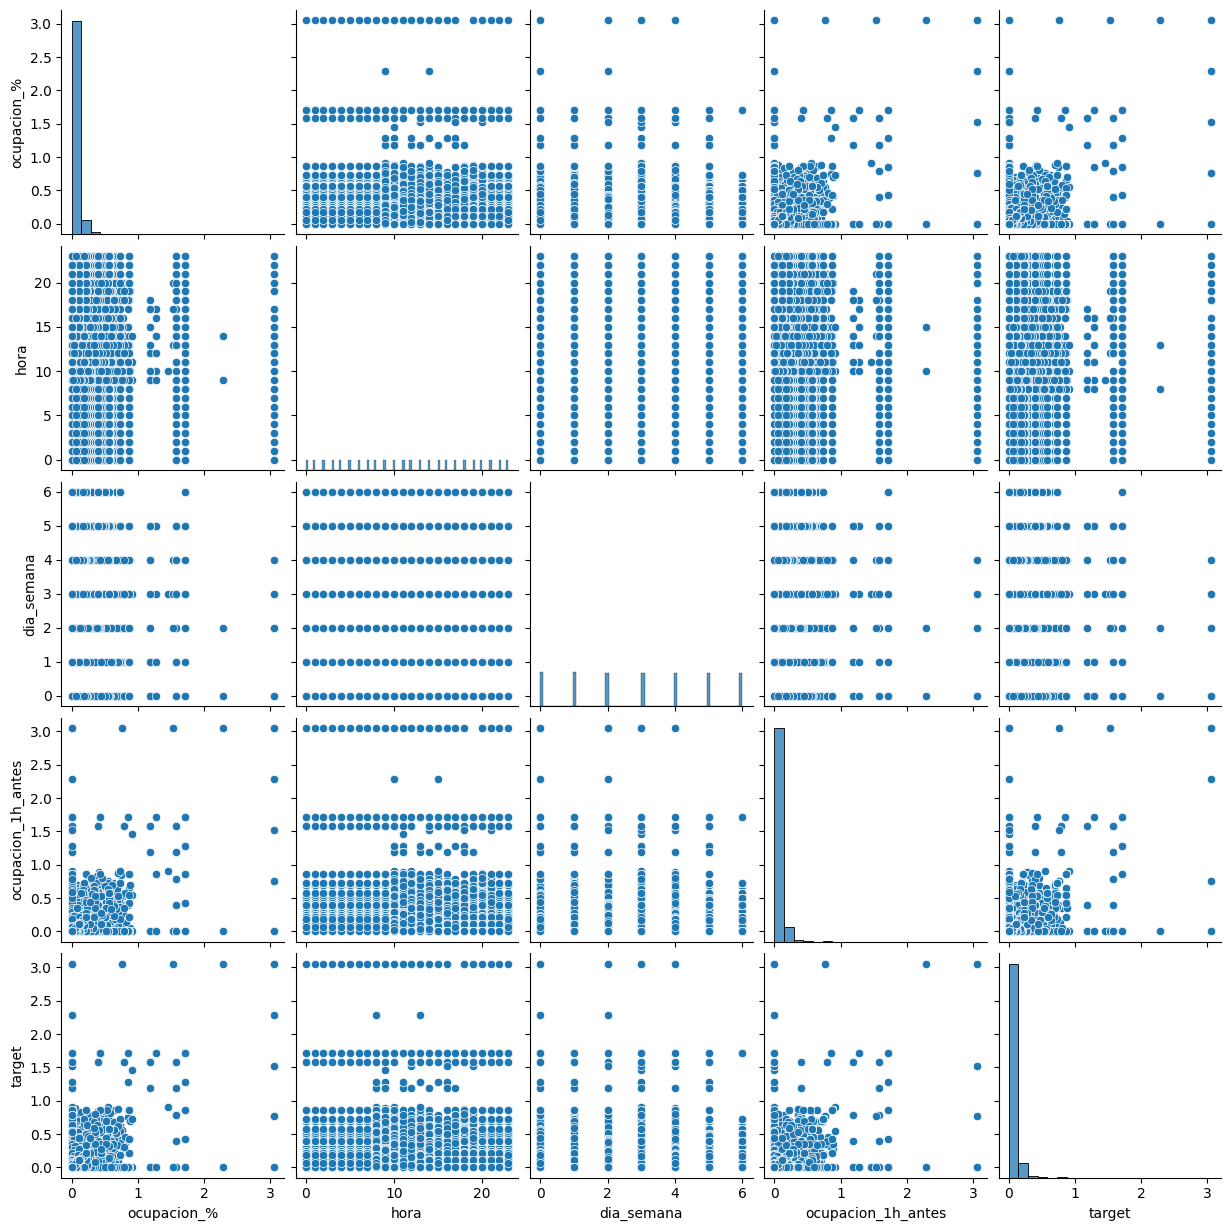

In [53]:
sns.pairplot(df)

<h3 style="color:red">IMPORTANTE!!</h3>

In [ ]:
# 1) Horario de pago (versión sencilla: 9-21 h todos los días)
mask_horario = df["hora"].between(9, 20)          # 20 ⇒ último slot 20-21 h

# 2) Filtra ceros “puros” (ambos = 0)
mask_ceros   = (df["ocupacion_%"] == 0) & (df["ocupacion_1h_antes"] == 0)

# 3) Dataset depurado
df_filt = df[mask_horario & ~mask_ceros].copy()

print(f"Filas antes: {len(df):,}  |  después: {len(df_filt):,}")

Filas antes: 553,266  |  después: 94,341


In [ ]:
df_filt["target"] = (df_filt
                        .groupby("barrio")["ocupacion_%"]
                        .shift(-1))
df_filt = df_filt.dropna(subset=["target"])


In [57]:
df_filt

,fecha_hora,barrio,ocupacion_%,hora,dia_semana,ocupacion_1h_antes,target
2024,2024-01-02 09:00:00,atocha,0.276625,9,1,0.000000,0.276625
2025,2024-01-02 09:00:00,bellas vistas,0.158353,9,1,0.000000,0.158353
2026,2024-01-02 09:00:00,berruguete,0.107875,9,1,0.000000,0.000000
2028,2024-01-02 09:00:00,casa de campo,0.089969,9,1,0.000000,0.134953
2029,2024-01-02 09:00:00,castellana,0.338123,9,1,0.000000,0.211327
...,...,...,...,...,...,...,...
553028,2024-12-31 19:00:00,castilla,0.111701,19,1,0.111701,0.111701
553037,2024-12-31 19:00:00,delicias,0.123609,19,1,0.123609,0.123609
553040,2024-12-31 19:00:00,estrella,0.115307,19,1,0.115307,0.115307
553064,2024-12-31 19:00:00,quintana,0.223214,19,1,0.223214,0.223214


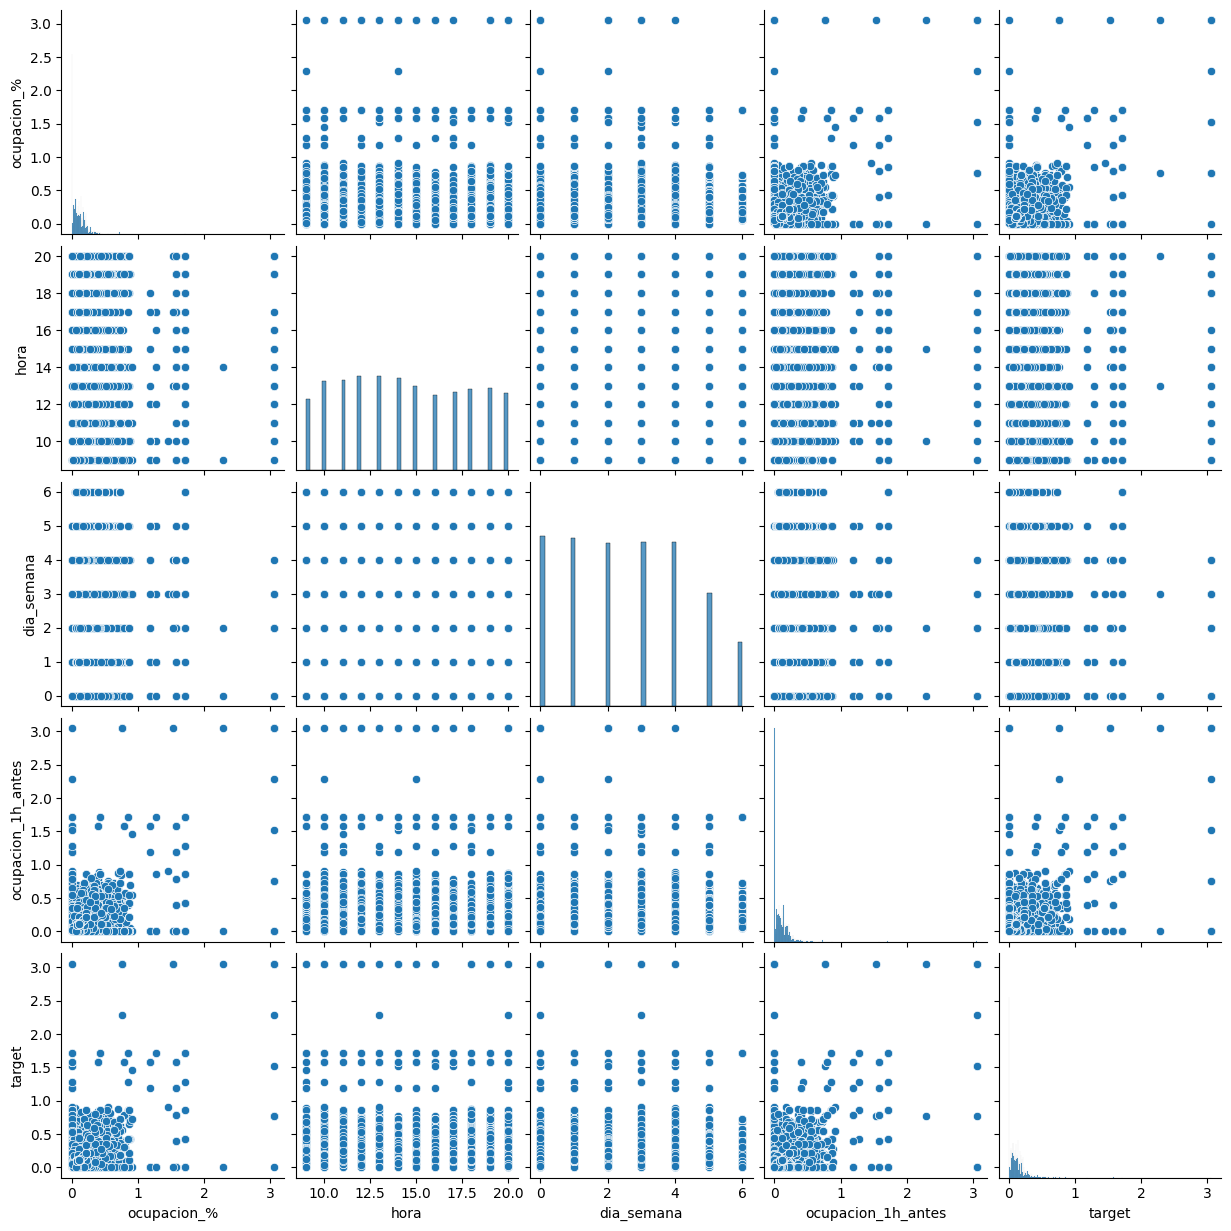

In [58]:
sns.pairplot(df_filt)

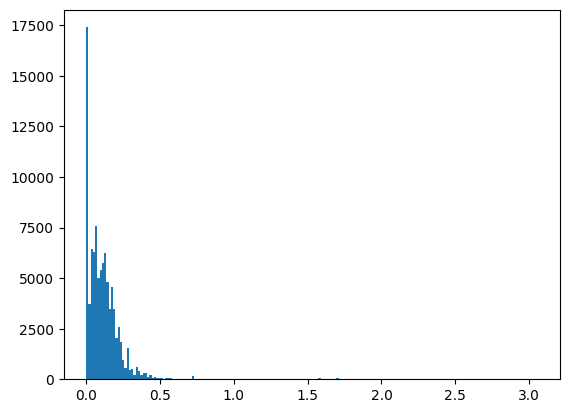

In [66]:
plt.hist(df_filt['target'], bins=200);

In [67]:
df_filt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94278 entries, 2024 to 553069
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   fecha_hora          94278 non-null  datetime64[ns]
 1   barrio              94278 non-null  object        
 2   ocupacion_%         94278 non-null  float64       
 3   hora                94278 non-null  int64         
 4   dia_semana          94278 non-null  int64         
 5   ocupacion_1h_antes  94278 non-null  float64       
 6   target              94278 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(1)
memory usage: 5.8+ MB


<h3 style="color:yellow">Modelo Base</3>

In [ ]:
#One-Hot Encoding de 'barrio'
df_filt = pd.get_dummies(df_filt, columns=["barrio"], drop_first=True)

In [75]:
df_filt.head()

,fecha_hora,ocupacion_%,hora,dia_semana,ocupacion_1h_antes,target,barrio_adelfas,barrio_almagro,barrio_almenara,barrio_almendrales,...,barrio_san isidro,barrio_san juan bautista,barrio_san pascual,barrio_sol,barrio_trafalgar,barrio_universidad,barrio_valdeacederas,barrio_valdezarza,barrio_vallehermoso,barrio_ventas
2024,2024-01-02 09:00:00,0.276625,9,1,0.0,0.276625,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2025,2024-01-02 09:00:00,0.158353,9,1,0.0,0.158353,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2026,2024-01-02 09:00:00,0.107875,9,1,0.0,0.000000,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2028,2024-01-02 09:00:00,0.089969,9,1,0.0,0.134953,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2029,2024-01-02 09:00:00,0.338123,9,1,0.0,0.211327,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [76]:
# Features y Target
X = df_filt.drop(columns=['fecha_hora', 'target'])
y = df_filt['target']

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    shuffle=False,
    random_state=10
)

In [78]:
# Estandardización
cols_a_escalar = ["ocupacion_%", "ocupacion_1h_antes", "hora", "dia_semana"]

scaler = StandardScaler()
X_train[cols_a_escalar] = scaler.fit_transform(X_train[cols_a_escalar])
X_test[cols_a_escalar]  = scaler.transform(X_test[cols_a_escalar])


In [79]:
X_train

,ocupacion_%,hora,dia_semana,ocupacion_1h_antes,barrio_adelfas,barrio_almagro,barrio_almenara,barrio_almendrales,barrio_arapiles,barrio_arguelles,...,barrio_san isidro,barrio_san juan bautista,barrio_san pascual,barrio_sol,barrio_trafalgar,barrio_universidad,barrio_valdeacederas,barrio_valdezarza,barrio_vallehermoso,barrio_ventas
2024,1.362117,-1.589322,-0.862314,-0.885712,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2025,0.388702,-1.589322,-0.862314,-0.885712,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2026,-0.026749,-1.589322,-0.862314,-0.885712,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2028,-0.174124,-1.589322,-0.862314,-0.885712,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2029,1.868266,-1.589322,-0.862314,-0.885712,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
451145,0.241349,-1.294191,0.781360,0.281119,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
451146,-0.681108,-1.294191,0.781360,-0.885712,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
451155,0.196110,-1.294191,0.781360,-0.138268,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
451156,1.172552,-1.294191,0.781360,0.869959,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [80]:
# Modelo Regresión Lineal
lr = LinearRegression()
lr.fit(X_train, y_train)

pred = lr.predict(X_test)
mae  = mean_absolute_error(y_test, pred)

print(f"MAE base: {mae} puntos porcentuales")


MAE base: 0.06365758068766945 puntos porcentuales
